In [3]:
import pandas as pd
import protfasta
import glob

In [4]:
# Fasta files and existing databases are from Input data clusters.ipynb

# Running mmseqs2
Generating commands (run from mmseqs folder of output)

In [5]:
def db_name(prefix, min_seq_id=0.5, fasta_path=False):
    if fasta_path:
        print(f"mmseqs createdb {fasta_path} {prefix}_DB") # - this alr exists
    id_thresh = int(min_seq_id * 100)
    print(f"mmseqs cluster {prefix}_DB {prefix}_DB_clu_id{id_thresh} {prefix}tmp_id{id_thresh} --min-seq-id {min_seq_id}")                      
    print(f"mmseqs createtsv {prefix}_DB {prefix}_DB {prefix}_DB_clu_id{id_thresh} {prefix}_DB_clu_id{id_thresh}.tsv")


In [7]:
# after removing structured proteins, how many clusters?
db_name("CL_SK_plant_seqs_disord_thresh", 0.75, "../../data/CL_SK_plant_seqs_disord_thresh.fasta")
print()

mmseqs createdb ../../data/CL_SK_plant_seqs_disord_thresh.fasta CL_SK_plant_seqs_disord_thresh_DB
mmseqs cluster CL_SK_plant_seqs_disord_thresh_DB CL_SK_plant_seqs_disord_thresh_DB_clu_id75 CL_SK_plant_seqs_disord_threshtmp_id75 --min-seq-id 0.75
mmseqs createtsv CL_SK_plant_seqs_disord_thresh_DB CL_SK_plant_seqs_disord_thresh_DB CL_SK_plant_seqs_disord_thresh_DB_clu_id75 CL_SK_plant_seqs_disord_thresh_DB_clu_id75.tsv



In [ ]:
CL_SK_plant_seqs_disord_thresh_DB_clu_id75 = pd.read_csv("../output/mmseqs/CL_SK_plant_seqs_disord_thresh_DB_clu_id75.tsv", sep = "\t", header = None)
# These are the roughly 240k Sequences I want to train the consensus model on!
pd.DataFrame(CL_SK_plant_seqs_disord_thresh_DB_clu_id75[0].value_counts()).reset_index()

,0,count
0,A0A452V6A1,544
1,A0A7K8ZQK0,499
2,H3BAF8,426
3,g000739.m1_yHMPu5000034983_candida_tsuchiyae_2...,344
4,A0A6P5JAN9,300
...,...,...
243146,Zosma10g00510.1,1
243147,Zosma287g00130.1,1
243148,Zosma20g01410.1,1
243149,Zosma115g00200.1,1


In [11]:
db_name("SK", 0.5)
print()
db_name("CL", 0.5) # Took about 6.5 min
print()

mmseqs cluster SK_DB SK_DB_clu_id50 SKtmp_id50 --min-seq-id 0.5
mmseqs createtsv SK_DB SK_DB SK_DB_clu_id50 SK_DB_clu_id50.tsv

mmseqs cluster CL_DB CL_DB_clu_id50 CLtmp_id50 --min-seq-id 0.5
mmseqs createtsv CL_DB CL_DB CL_DB_clu_id50 CL_DB_clu_id50.tsv



In [ ]:
# after removing structured proteins, how many clusters?
db_name("SK_CL_disord", 0.75, "../SK_CL_disord_input.fasta")
print()

mmseqs createdb ../SK_CL_disord_input.fasta SK_CL_disord_DB
mmseqs cluster SK_CL_disord_DB SK_CL_disord_DB_clu_id75 SK_CL_disordtmp_id75 --min-seq-id 0.75
mmseqs createtsv SK_CL_disord_DB SK_CL_disord_DB SK_CL_disord_DB_clu_id75 SK_CL_disord_DB_clu_id75.tsv



In [ ]:
# Running these jobs using ../scripts/run_mmseqs_parallel.sh from mmseqs folder of output, with conda mmseqs2 environment activated
db_name("SK", 0.75)
print()
db_name("SK", 0.9)
print()
db_name("CL", 0.75)
print()
db_name("CL", 0.9)
print()
db_name("CL_SK", 0.5)
print()
db_name("CL_SK", 0.75)
print()
db_name("CL_SK", 0.9)

mmseqs cluster SK_DB SK_DB_clu_id75 SKtmp_id75 --min-seq-id 0.75
mmseqs createtsv SK_DB SK_DB SK_DB_clu_id75 SK_DB_clu_id75.tsv

mmseqs cluster SK_DB SK_DB_clu_id90 SKtmp_id90 --min-seq-id 0.9
mmseqs createtsv SK_DB SK_DB SK_DB_clu_id90 SK_DB_clu_id90.tsv

mmseqs cluster CL_DB CL_DB_clu_id75 CLtmp_id75 --min-seq-id 0.75
mmseqs createtsv CL_DB CL_DB CL_DB_clu_id75 CL_DB_clu_id75.tsv

mmseqs cluster CL_DB CL_DB_clu_id90 CLtmp_id90 --min-seq-id 0.9
mmseqs createtsv CL_DB CL_DB CL_DB_clu_id90 CL_DB_clu_id90.tsv

mmseqs cluster CL_SK_DB CL_SK_DB_clu_id50 CL_SKtmp_id50 --min-seq-id 0.5
mmseqs createtsv CL_SK_DB CL_SK_DB CL_SK_DB_clu_id50 CL_SK_DB_clu_id50.tsv

mmseqs cluster CL_SK_DB CL_SK_DB_clu_id75 CL_SKtmp_id75 --min-seq-id 0.75
mmseqs createtsv CL_SK_DB CL_SK_DB CL_SK_DB_clu_id75 CL_SK_DB_clu_id75.tsv

mmseqs cluster CL_SK_DB CL_SK_DB_clu_id90 CL_SKtmp_id90 --min-seq-id 0.9
mmseqs createtsv CL_SK_DB CL_SK_DB CL_SK_DB_clu_id90 CL_SK_DB_clu_id90.tsv


In [20]:
# Disorder filered
SK_CL_disord_DB_clu_id75 = pd.read_csv("../output/mmseqs/SK_CL_disord_DB_clu_id75.tsv", sep = "\t", header = None)
SK_CL_disord_DB_clu_id75[0].value_counts()

0
A0A452V6A1                                                                  542
A0A8C8RRW6                                                                  506
H3BAF8                                                                      426
A0A7K9TUQ7                                                                  370
A0A6P5JAN9                                                                  281
                                                                           ... 
g005841.m1_yHAB155_kazachstania_spencerorum_160519.final                      1
g004319.m1_yHAB147_kazachstania_taianensis_160519.final                       1
g000797.m1_yHAB133_kazachstania_unispora_160519.final                         1
g001867.m1_saprochaete_suaveolens.final                                       1
g001507.m1_yHMPu5000037227_cyberlindnera_xishuangbannaensis_210210.final      1
Name: count, Length: 99035, dtype: int64

In [30]:
SK_CL_disord_DB_clu_id75_sizes = pd.DataFrame(SK_CL_disord_DB_clu_id75[0].value_counts()).reset_index()
SK_CL_disord_DB_clu_id75_sizes[SK_CL_disord_DB_clu_id75_sizes["count"] > 10]["count"]


0       542
1       506
2       426
3       370
4       281
       ... 
1456     11
1457     11
1458     11
1459     11
1460     11
Name: count, Length: 1461, dtype: int64

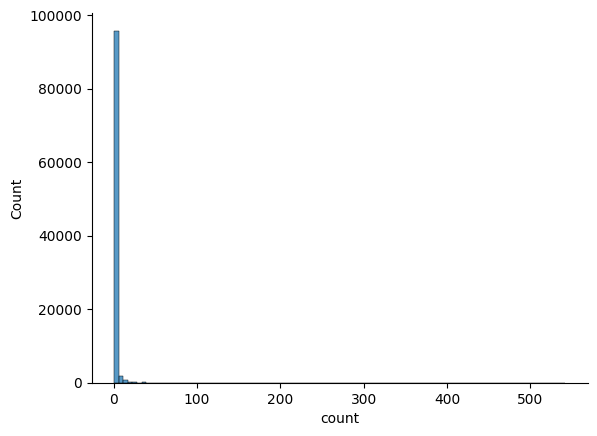

In [37]:
# Most clusters are small
import seaborn as sns

sns.histplot(SK_CL_disord_DB_clu_id75_sizes["count"], bins = 100)
sns.despine()

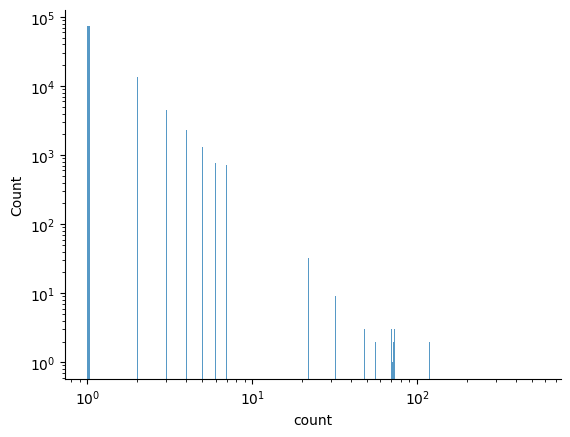

In [38]:

ax = sns.histplot(SK_CL_disord_DB_clu_id75_sizes["count"])
ax.set_yscale('log')
ax.set_xscale('log')
sns.despine()

# 1. SK seqs alone

In [ ]:
SK_clusters_50 = pd.read_csv("../output/mmseqs/SK_DB_clu_id50.tsv", sep = "\t", header = None)
SK_clusters_50[0].value_counts()

0
A0A8C3JAW5    981
A0A8C8RRW6    688
A0A7M4FRM1    624
W5LVU9        588
Q9LL98        551
             ... 
K7ISY1          1
K4PZ55          1
J3JUA3          1
G3XFD9          1
A0A0P0WV74      1
Name: count, Length: 34134, dtype: int64

In [ ]:
SK_clusters_75 = pd.read_csv("../output/mmseqs/SK_DB_clu_id75.tsv", sep = "\t", header = None)
SK_clusters_75[0].value_counts()


0
A0A452V6A1    545
A0A7K8ZQK0    499
H3BAF8        426
A0A7K9TUQ7    372
A0A6J1ZEQ1    307
             ... 
V9KNJ4          1
V9L3K8          1
W5UBB2          1
A0A0A7PCA9      1
H9KUY5          1
Name: count, Length: 58512, dtype: int64

In [50]:
SK_clusters_90 = pd.read_csv("../output/mmseqs/SK_DB_clu_id90.tsv", sep = "\t", header = None)
SK_clusters_90[0].value_counts()

0
A0A2K5CRD1    402
A0A7L2TWH2    315
A0A8B9ZRK4    267
A0A8C9EKD2    236
A0A287B140    225
             ... 
F2D0W0          1
F2Y9U6          1
I3S7S2          1
I4DKB3          1
A0A5N3UP41      1
Name: count, Length: 76098, dtype: int64

In [51]:
CL_clusters_50 = pd.read_csv("../output/mmseqs/CL_DB_clu_id50.tsv", sep = "\t", header = None)
CL_clusters_50[0].value_counts()

0
g004062.m1_yHMPu5000035258_wickerhamomyces_subpelliculosus_160928.haplomerger2.final    1069
g003969.m1_yHMPu5000034633_candida_smithsonii_180604.final                               763
g002011.m1_yHMPu5000037207_Wickerhamomyces_kurtzmanii_SPADES.final                       436
g000817.m1_yHMPu5000037873_debaryomyces_udenii_180604.final                              390
g001129.m1_yHMPu5000035018_candida_canberraensis_160519.final                            311
                                                                                        ... 
g000499.m1_yHMPu5000038388_candida_inconspicua_170713.final                                1
g000761.m1_yHMPu5000034958_hanseniaspora_opuntiae_201018.haplomerger2.final                1
g002965.m1_yHMPu5000034684_blastobotrys_attinorum_201018.final                             1
g001958.m1_yHMPu5000034946_ambrosiozyma_oregonensis_160519.final                           1
g003648.m1_yHMPu5000038114_candida_anutae_170912.final              

In [52]:
CL_clusters_75 = pd.read_csv("../output/mmseqs/CL_DB_clu_id75.tsv", sep = "\t", header = None)
CL_clusters_75[0].value_counts()

0
g004511.m1_yHMPu5000038331_metschnikowia_lopburiensis_170713.final               71
g007418.m1_yHMPu5000041701_Candida_jeffriesii_SPADES.haplomerger2.final          51
g005031.m1_yHMPu5000041779_schwanniomyces_pseudopolymorphus_190924.final         39
g006441.m1_yHMPu5000041804_metschnikowia_vanudenii_190924.final                  38
g001658.m1_yHQL142_Suhomyces_sp_nov_plate33_DISCOVAR.final                       34
                                                                                 ..
g006473.m1_yHMPu5000035273_wickerhamomyces_anomalus_180604.haplomerger2.final     1
g000130.m1_yHMPu5000035296_priceomyces_carsonii_160928.final                      1
g001463.m1_yHMPu5000035308_nadsonia_starkeyi-henricii_180604.final                1
g004051.m1_yHMPu5000035320_candida_auringiensis_190924.final                      1
g002280.m1_yHMPu5000038384_candida_molendinolei_170713.final                      1
Name: count, Length: 71616, dtype: int64

In [53]:
CL_clusters_90 = pd.read_csv("../output/mmseqs/CL_DB_clu_id75.tsv", sep = "\t", header = None)
CL_clusters_90[0].value_counts()

0
g004511.m1_yHMPu5000038331_metschnikowia_lopburiensis_170713.final               71
g007418.m1_yHMPu5000041701_Candida_jeffriesii_SPADES.haplomerger2.final          51
g005031.m1_yHMPu5000041779_schwanniomyces_pseudopolymorphus_190924.final         39
g006441.m1_yHMPu5000041804_metschnikowia_vanudenii_190924.final                  38
g001658.m1_yHQL142_Suhomyces_sp_nov_plate33_DISCOVAR.final                       34
                                                                                 ..
g006473.m1_yHMPu5000035273_wickerhamomyces_anomalus_180604.haplomerger2.final     1
g000130.m1_yHMPu5000035296_priceomyces_carsonii_160928.final                      1
g001463.m1_yHMPu5000035308_nadsonia_starkeyi-henricii_180604.final                1
g004051.m1_yHMPu5000035320_candida_auringiensis_190924.final                      1
g002280.m1_yHMPu5000038384_candida_molendinolei_170713.final                      1
Name: count, Length: 71616, dtype: int64

In [55]:
CL_SK_clusters_50 = pd.read_csv("../output/mmseqs/CL_SK_DB_clu_id50.tsv", sep = "\t", header = None)
CL_SK_clusters_50[0].value_counts()

0
g000942.m1_yHMPu5000034957_Hanseniaspora_osmophila_SPADES.final    1377
g001365.m1_yHMPu5000035662_meyerozyma_caribbica_160613.final        719
A0AAV2ZPF1                                                          688
A0A7M4FRM1                                                          624
A0A444UNR1                                                          588
                                                                   ... 
g001893.m1_yHMPu5000038119_candida_coquimbonensis_170912.final        1
g004721.m1_yHMPu5000041821_geotrichum_cucujoidarum_170912.final       1
g000109.m1_yHMPu5000041851_candida_krabiensis_160928.final            1
g005390.m1_yHAB136_kazachstania_bromeliacearum_160519.final           1
g000552.m1_yHMH443_Groenewaldozyma_sp_nov_plate33_SPADES.final        1
Name: count, Length: 64198, dtype: int64

In [69]:
CL_SK_clusters_75 = pd.read_csv("../output/mmseqs/CL_SK_DB_clu_id75.tsv", sep = "\t", header = None)
CL_SK_clusters_75[0].value_counts()

0
A0A452V6A1                                                545
A0A8C8RRW6                                                506
H3BAF8                                                    426
A0A6J1ZI12                                                306
A0A6P5JAN9                                                302
                                                         ... 
Q9NFP4                                                      1
Q70HR7                                                      1
F1LGC5                                                      1
B5AXG5                                                      1
g003768.m1_yHDO570_kluyveromyces_starmeri_180604.final      1
Name: count, Length: 128853, dtype: int64

In [92]:
CL_SK_clusters_90 = pd.read_csv("../output/mmseqs/CL_SK_DB_clu_id90.tsv", sep = "\t", header = None)
CL_SK_clusters_90[0].value_counts()

0
A0A2K5CRD1                                                       402
A0A7L2TWH2                                                       319
A0A8B9ZRK4                                                       267
A0A8C9EKD2                                                       229
A0A287B140                                                       225
                                                                ... 
g000903.m1_yHMPu5000038360_candida_verbasci_170713.final           1
g005858.m1_yHMPu5000038379_candida_lidongshanica_180604.final      1
g002310.m1_yHMPu5000038408_candida_borneonana_170713.final         1
g004864.m1_yHMPu5000040918_candida_insectamans_201018.final        1
P11065                                                             1
Name: count, Length: 168053, dtype: int64

In [88]:
# our input
import os
import subprocess

CL_SK_input  = protfasta.read_fasta("../data/CL_SK_input.fasta", invalid_sequence_action='ignore')
CL_SK_input = pd.DataFrame({"id" : CL_SK_input.keys(), "seq": CL_SK_input.values()})
CL_SK_input["uniprotID"] = CL_SK_input["id"].str.split("|").str[1]
CL_SK_input["uniprotID"] = CL_SK_input["uniprotID"].fillna(CL_SK_input["id"])


def align_largest_input(cluster_id, CL_SK_clusters_75):

    cluster_id = str(cluster_id)  # Ensure it's a string
    # Get all IDs in the cluster
    cluster_ids = CL_SK_clusters_75[CL_SK_clusters_75[0] == cluster_id][1]
    similarity_set = CL_SK_input[CL_SK_input["uniprotID"].isin(cluster_ids)]

    # Write sequences to FASTA
    fasta_path = f"../output/cluster_{cluster_id}.fasta"
    protfasta.write_fasta(dict(zip(similarity_set["uniprotID"], similarity_set["seq"])), fasta_path)

    # Align using MAFFT
    aligned_path = f"../output/cluster_{cluster_id}_aligned.fasta"
    subprocess.run(["mafft", "--auto", fasta_path], stdout=open(aligned_path, "w"), check=True)


In [89]:
align_largest_input("A0A452V6A1", CL_SK_clusters_75)

python(21267) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
nthread = 0
nthreadpair = 0
nthreadtb = 0
ppenalty_ex = 0
stacksize: 8176 kb
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00



Making a distance matrix ..
  501 / 545
done.

Constructing a UPGMA tree (efffree=0) ... 
  540 / 545
done.

Progressive alignment 1/2... 
STEP   396 / 544 
Reallocating..done. *alloclen = 3647
STEP   501 / 544 
done.

Making a distance matrix from msa.. 
  500 / 545
done.

Constructing a UPGMA tree (efffree=1) ... 
  540 / 545
done.

Progressive alignment 2/2... 
STEP   418 / 544 
Reallocating..done. *alloclen = 3392
STEP   501 / 544 
done.

disttbfast (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 FFT-NS-2 (Fast but rough)
 Progressive method (guide trees were built 2 times.)

If unsure which option to use, try 'mafft --auto input > output'.
For more information, see 'mafft --help', 'mafft --man' and the ma

In [91]:
align_largest_input("g000942.m1_yHMPu5000034957_Hanseniaspora_osmophila_SPADES.final", CL_SK_clusters_50)

python(21383) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
nthread = 0
nthreadpair = 0
nthreadtb = 0
ppenalty_ex = 0
stacksize: 8176 kb
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00



Making a distance matrix ..

There are 37 ambiguous characters.
 1301 / 1377
done.

Constructing a UPGMA tree (efffree=0) ... 
 1370 / 1377
done.

Progressive alignment 1/2... 
STEP  1201 / 1376 
Reallocating..done. *alloclen = 2014
STEP  1301 / 1376 
done.

Making a distance matrix from msa.. 
 1300 / 1377
done.

Constructing a UPGMA tree (efffree=1) ... 
 1370 / 1377
done.

Progressive alignment 2/2... 
STEP   272 / 1376 

STEP  1201 / 1376 
Reallocating..done. *alloclen = 1978
STEP  1301 / 1376 
done.

disttbfast (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 FFT-NS-2 (Fast but rough)
 Progressive method (guide trees were built 2 times.)

If unsure which option to use, try 'mafft --auto input > output'.
For more information, see 'mafft --help', 'mafft --man' and the mafft page.

The default gap scoring scheme has been changed in version 7.110 (2013 Oct).
It tends to insert more gaps into gap-rich regions than previous versions.
To disable this change, add the --leavegappyregion option.



In [93]:
align_largest_input("A0A2K5CRD1", CL_SK_clusters_90)

python(21513) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
nthread = 0
nthreadpair = 0
nthreadtb = 0
ppenalty_ex = 0
stacksize: 8176 kb
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00



Making a distance matrix ..
  401 / 402
done.

Constructing a UPGMA tree (efffree=0) ... 
  400 / 402
done.

Progressive alignment 1/2... 
STEP   399 / 401 
Reallocating..done. *alloclen = 2257
STEP   401 / 401 
done.

Making a distance matrix from msa.. 
  400 / 402
done.

Constructing a UPGMA tree (efffree=1) ... 
  400 / 402
done.

Progressive alignment 2/2... 
STEP   398 / 401 
Reallocating..done. *alloclen = 2245
STEP   401 / 401 
done.

disttbfast (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)

distout=h
rescale = 1
dndpre (aa) Version 7.526
alg=X, model=BLOSUM62, 1.53, +0.12, -0.00, noshift, amax=0.0
0 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200


In [6]:
# How long is the starting input?
len(protfasta.read_fasta("../data/CL_SK_input.fasta", invalid_sequence_action='remove'))

244548

In [ ]:
# Just my seqs
len(protfasta.read_fasta("../output/interpro_uniprot_evid_1_2.fasta", invalid_sequence_action='remove'))

137436

In [9]:
# Just Claire's seqs
len(protfasta.read_fasta("../output/cl_seqs.fasta", invalid_sequence_action='remove'))

110534